### **Machine Learning for Data Analytics**
### **Assignment 1**
#### Piotr czech, Filip Miśkiewicz

#### **Imports**

In [3]:
import time             # Used to track the exact duration of model training
import tracemalloc      # Used to measure the peak RAM consumption of our models
import warnings         # Used to suppress non-critical warnings that clutter the notebook
from typing import Dict, List, Tuple, Any # Used for strict Python type hinting (PEP 484)

import numpy as np      # Used for numerical operations and exponential/log transformations
import pandas as pd     # Used for loading, manipulating, and displaying data structures
import matplotlib.pyplot as plt  # Used for creating visualizations and plots
from IPython.display import display # Used to render Pandas DataFrames natively in Jupyter
from tqdm import tqdm          # Used to generate progress bars for long loops
from sklearn.model_selection import KFold  # Used for splitting data properly
from sklearn.metrics import root_mean_squared_error  # Used for calculating the primary error metric

from xgboost import XGBRegressor    # The XGBoost model class
from lightgbm import LGBMRegressor  # The LightGBM model class
from catboost import CatBoostRegressor # The CatBoost model class

In [4]:
# Suppress specific warnings (like LightGBM's categorical feature warnings) for a clean notebook UI
warnings.filterwarnings('ignore', category=UserWarning)

#### **Task 2**

In [5]:
def perform_basic_eda(df: pd.DataFrame) -> None:
    """
    Performs Basic Exploratory Data Analysis (EDA) using native Pandas display.
    
    Args:
        df (pd.DataFrame): The loaded dataset.
    """
    print("1. Dataset Shape:", df.shape)
    
    print("\n2. First 5 Rows (Head):")
    # Native display creates a beautifully formatted HTML table in Jupyter
    display(df.head())
    
    print("\n3. Missing Values Summary (Top 10 columns):")
    # Count missing values, filter out columns with 0 missing, and sort descending
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if missing_data.empty:
        print("No missing values found.")
    else:
        # Convert to DataFrame for pretty Jupyter rendering
        display(pd.DataFrame({'Missing Count': missing_data.head(10)}))
        
    print("\n4. Target Variable ('SalePrice') Summary:")
    if 'SalePrice' in df.columns:
        # Transpose the describe() output to make it easier to read horizontally
        display(pd.DataFrame(df['SalePrice'].describe()).T)
    else:
        print("Warning: 'SalePrice' column not found in the dataset.")

In [6]:
def load_and_preprocess_data(filepath: str) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """
    Loads the dataset, handles categorical missing values, and applies log transformation.
    
    Args:
        filepath (str): The local path to the house prices CSV file.
        
    Returns:
        X (pd.DataFrame): The feature matrix, safely copied and ready for training.
        y_log (pd.Series): The log-transformed target variable (SalePrice).
        cat_features (List[str]): A list of column names that contain categorical data.
    """
    # 1. Load the data from the provided CSV file
    df = pd.read_csv(filepath)
    
    # 2. Perform exploratory data analysis right after loading
    perform_basic_eda(df)
    
    # 3. Separate the target variable (what we want to predict) from the features
    y = df['SalePrice']
    # Use .copy() to ensure we create a distinct object in memory, avoiding SettingWithCopy warnings
    X = df.drop(columns=['SalePrice']).copy()
    
    # 4. Drop the 'Id' column. It is a unique identifier and holds no predictive value.
    if 'Id' in X.columns:
        X = X.drop(columns=['Id'])

    # 5. Log-transform the target. House prices are heavily right-skewed. 
    # Applying log(1+x) makes the distribution more normal, which helps trees learn better.
    y_log = np.log1p(y)

    # 6. Identify categorical features. Modern frameworks prefer pandas 'category' dtypes.
    cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
    
    for col in cat_features:
        # Fill missing categorical values with the string 'Missing'. 
        # This treats "missingness" as a valid category, which is often highly predictive.
        X[col] = X[col].fillna('Missing')
        # Convert the column dtype to 'category' so LightGBM and XGBoost recognize it natively
        X[col] = X[col].astype('category')
        
    # Note: We leave numerical missing values (NaNs) alone. 
    # XGBoost, LightGBM, and CatBoost all have native logic to route NaNs optimally during splits.
    return X, y_log, cat_features

In [7]:
def evaluate_model(
    model_name: str, 
    model: Any, 
    X: pd.DataFrame, 
    y_log: pd.Series, 
    cat_features: List[str],
    n_splits: int = 5
) -> Tuple[Dict[str, List[float]], np.ndarray]:
    """
    Evaluates a model using K-Fold CV. Tracks time, memory, RMSE in actual dollars, 
    and captures Out-Of-Fold (OOF) predictions.
    
    Args:
        model_name (str): Name of the model for display purposes.
        model (Any): The initialized machine learning model.
        X (pd.DataFrame): Feature matrix.
        y_log (pd.Series): Log-transformed target variable.
        cat_features (List[str]): List of categorical columns.
        n_splits (int): Number of folds for cross-validation.
        
    Returns:
        Tuple: 
            - Dict: Lists of metrics (RMSE in dollars, time, memory) recorded across all folds.
            - np.ndarray: The complete Out-Of-Fold predictions for the entire dataset.
    """
    # Initialize the K-Fold splitter. Shuffle=True ensures random distribution of data.
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Dictionary to store the metrics for each fold
    metrics = {
        'rmse_dollars': [],
        'time_sec': [],
        'memory_mb': []
    }
    
    # Array to store Out-Of-Fold predictions. We initialize it with zeros matching the dataset length.
    oof_preds_log = np.zeros(len(X))
    
    # Wrap the KFold generator in tqdm to display a progress bar in the notebook
    for train_idx, val_idx in tqdm(kf.split(X), total=n_splits, desc=f"Training {model_name}"):
        
        # Split the data into training and validation sets for this specific fold
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        # Start tracking time and peak memory consumption
        start_time = time.perf_counter()
        tracemalloc.start()
        
        # Fit the model. CatBoost requires the categorical features to be explicitly passed.
        if model_name == 'CatBoost':
            model.fit(X_train, y_train_log, cat_features=cat_features, verbose=False)
        else:
            model.fit(X_train, y_train_log)
            
        # Stop tracking memory and time once fitting is complete
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        end_time = time.perf_counter()
        
        # Predict on the validation set. These predictions are still in log scale.
        preds_log = model.predict(X_val)
        
        # Store these unbiased predictions in the exact indices they belong to
        oof_preds_log[val_idx] = preds_log
        
        # REVERT TRANSFORMATION: Apply exponential minus 1 to get back to original dollar values
        preds_dollar = np.expm1(preds_log)
        y_val_dollar = np.expm1(y_val_log)
        
        # Calculate standard RMSE on the dollar values for this specific fold
        rmse_dollar = root_mean_squared_error(y_val_dollar, preds_dollar)
        
        # Append the calculated metrics for this fold to our tracking dictionary
        metrics['rmse_dollars'].append(rmse_dollar)
        metrics['time_sec'].append(end_time - start_time)
        metrics['memory_mb'].append(peak_mem / (1024 * 1024)) # Convert bytes to Megabytes
        
    return metrics, oof_preds_log

In [8]:
def plot_oof_predictions(oof_predictions: Dict[str, np.ndarray], y_log: pd.Series) -> None:
    """
    Generates a scatter plot of True vs OOF Predicted values to visualize model performance.
    
    Args:
        oof_predictions (Dict): Dictionary mapping model names to their OOF prediction arrays (in log scale).
        y_log (pd.Series): Complete log-transformed true target.
    """
    # Revert true target back to dollars for the axes
    y_true_dollar = np.expm1(y_log)
    
    # Initialize a 1x3 subplot figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Actual vs. OOF Predicted Sale Prices (Cross-Validated)', fontsize=16)
    
    for ax, (name, preds_log) in zip(axes, oof_predictions.items()):
        # Revert OOF predictions back to dollars
        preds_dollar = np.expm1(preds_log)
        
        # Plot the scatter points (True vs Predicted)
        ax.scatter(y_true_dollar, preds_dollar, alpha=0.5, color='steelblue', edgecolor='k')
        
        # Plot the perfect prediction diagonal line (y = x)
        max_val = max(y_true_dollar.max(), preds_dollar.max())
        min_val = min(y_true_dollar.min(), preds_dollar.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Prediction')
        
        # Format the axes and titles
        ax.set_title(f"{name} (OOF Results)")
        ax.set_xlabel('True Price ($)')
        ax.set_ylabel('Predicted Price ($)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

#### Execution

In [9]:
# Update this path if necessary to point to your local dataset
data_path = "data/house_prices.csv"

# Load data and apply preprocessing (handling cat missing values, logging target)
X, y_log, cat_features = load_and_preprocess_data(data_path)

# Define baseline hyperparameters to keep the comparison fair across algorithms
common_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'random_state': 42
}

# Initialize the three frameworks
models = {
    # tree_method='hist' allows XGBoost to handle categorical data natively
    'XGBoost': XGBRegressor(**common_params, max_depth=6, tree_method='hist', enable_categorical=True),
    # num_leaves=63 is roughly equivalent to max_depth=6 for LightGBM's leaf-wise growth
    'LightGBM': LGBMRegressor(**common_params, max_depth=6, num_leaves=63, verbose=-1),
    # CatBoost is naturally slower on CPUs. allow_writing_files=False prevents clutter.
    'CatBoost': CatBoostRegressor(**common_params, depth=6, verbose=False, allow_writing_files=False)
}

all_metrics = {}
all_oof_preds = {}

print("\nStarting robust cross-validation evaluation (capturing OOF predictions)...")
# Iterate through models, evaluate them, and store both the metrics and the OOF predictions
for name, model in models.items():
    metrics, oof_preds = evaluate_model(name, model, X, y_log, cat_features)
    all_metrics[name] = metrics
    all_oof_preds[name] = oof_preds

# Compile the tracked metrics into a list of dictionaries to create a clean Pandas DataFrame
results_list = []
for name, metrics in all_metrics.items():
    results_list.append({
        'Model': name,
        'Best RMSE ($)': np.min(metrics['rmse_dollars']),
        'Worst RMSE ($)': np.max(metrics['rmse_dollars']),
        'Avg RMSE ($)': np.mean(metrics['rmse_dollars']),
        'Best Time (s)': np.min(metrics['time_sec']),
        'Worst Time (s)': np.max(metrics['time_sec']),
        'Avg Time (s)': np.mean(metrics['time_sec']),
        'Avg Peak Mem (MB)': np.mean(metrics['memory_mb'])
    })

# Convert to DataFrame, set the model name as the index, and display natively in Jupyter
results_df = pd.DataFrame(results_list)
results_df.set_index('Model', inplace=True)

1. Dataset Shape: (1460, 81)

2. First 5 Rows (Head):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



3. Missing Values Summary (Top 10 columns):


,Missing Count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81



4. Target Variable ('SalePrice') Summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0



Starting robust cross-validation evaluation (capturing OOF predictions)...


Training CatBoost: 100%|██████████| 5/5 [06:18<00:00, 75.78s/it]


In [10]:
print("\nFinal Model Comparison (Original Dollar Scale):")
# Use native display and round the results for clean readability
display(results_df.round(2)) 


Final Model Comparison (Original Dollar Scale):


,Best RMSE ($),Worst RMSE ($),Avg RMSE ($),Best Time (s),Worst Time (s),Avg Time (s),Avg Peak Mem (MB)
Model,,,,,,,
XGBoost,24622.25,38724.06,30350.87,3.54,10.73,7.58,0.57
LightGBM,21655.54,37585.63,28389.59,0.80,1.20,0.93,4.96
CatBoost,19287.68,42777.60,27907.58,73.11,81.67,75.77,0.16



Generating rigorous OOF prediction performance plots...


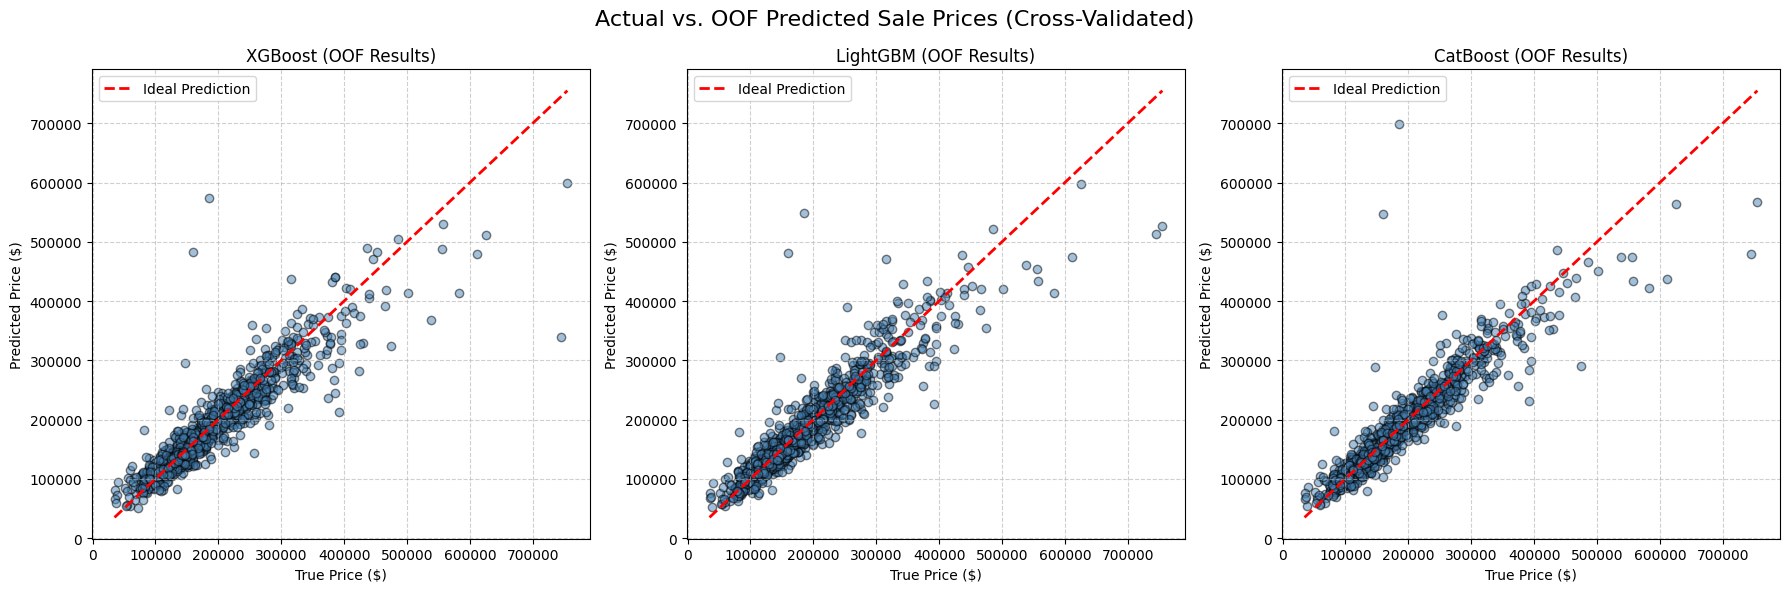

In [11]:
# Generate the visual performance plots using the unbiased OOF predictions
print("\nGenerating rigorous OOF prediction performance plots...")
plot_oof_predictions(all_oof_preds, y_log)